In [2]:
import pandas as pd

# Read data
df = pd.read_csv(
    r"C:\DEEP LEARNING\final project deep learning\archive (2)\METABRIC_RNA_Mutation.csv",
    low_memory=False
)

# Keep only 4 subtypes
df = df[df["pam50_+_claudin-low_subtype"].isin(["LumA", "LumB", "Her2", "Basal"])].copy()

# Drop mutation columns
mutation_cols = [col for col in df.columns if col.endswith("_mut")]
df_combined = df.drop(columns=mutation_cols)

# Drop ID / target leakage / outcome columns
drop_cols = [
    "patient_id",
    "overall_survival",
    "overall_survival_months",
    "death_from_cancer",
    "3-gene_classifier_subtype"
]

df_combined = df_combined.drop(columns=drop_cols, errors="ignore")
df_combined

,age_at_diagnosis,type_of_breast_surgery,cancer_type,cancer_type_detailed,cellularity,chemotherapy,pam50_+_claudin-low_subtype,cohort,er_status_measured_by_ihc,er_status,...,srd5a1,srd5a2,srd5a3,st7,star,tnk2,tulp4,ugt2b15,ugt2b17,ugt2b7
1,43.19,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumA,1,Positve,Positive,...,-0.4412,0.4534,0.4068,0.7634,0.0231,0.9121,-0.9538,-0.2264,0.5398,-0.8920
2,48.87,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,1,LumB,1,Positve,Positive,...,-0.5381,0.0668,0.8344,1.7227,0.4024,-3.7172,-1.5538,1.3701,-0.1078,0.3655
3,47.68,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,1,LumB,1,Positve,Positive,...,-0.5630,-0.7078,0.8228,0.6819,-0.1948,-2.3286,-0.9924,-0.3154,0.2320,-0.4828
4,76.97,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,1,LumB,1,Positve,Positive,...,-0.5845,-0.3544,-1.0150,2.2961,0.1817,-0.1572,0.0427,5.0048,3.8476,1.3223
5,78.77,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,Moderate,0,LumB,1,Positve,Positive,...,-0.3910,0.0395,0.8191,0.1977,-0.2302,-0.5092,-0.3021,0.9357,-0.4217,0.5340
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1899,43.10,BREAST CONSERVING,Breast Cancer,Breast Invasive Lobular Carcinoma,High,0,LumA,4,Positve,Positive,...,0.7859,1.5304,1.1196,0.8116,0.0958,-1.2644,-0.3566,-0.2615,-0.6371,-0.5540
1900,42.88,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumB,4,Positve,Positive,...,-0.5294,-0.6610,-0.1610,0.2251,0.5127,-0.3412,-1.0703,-0.6950,0.0641,-0.8863
1901,62.90,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumB,4,Positve,Positive,...,-0.1457,-0.5194,2.3968,0.5917,-0.8643,-1.3541,-1.8076,-0.1840,0.0967,-0.6264
1902,61.16,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,Moderate,0,LumB,4,Positve,Positive,...,-0.6380,-1.5275,1.1070,0.2194,1.4317,-0.6985,-0.6046,-0.4915,-0.2847,-0.8041


In [3]:
X_combined = df_combined.drop(columns=["pam50_+_claudin-low_subtype"])
y_combined = df_combined["pam50_+_claudin-low_subtype"]

In [5]:
missing = X_combined.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

tumor_stage                       420
primary_tumor_laterality           86
neoplasm_histologic_grade          57
cellularity                        28
er_status_measured_by_ihc          25
mutation_count                     20
type_of_breast_surgery             15
cancer_type_detailed               12
tumor_other_histologic_subtype     12
oncotree_code                      12
tumor_size                         12
dtype: int64

In [6]:
X_combined = X_combined.drop(columns=["tumor_stage"], errors="ignore")

In [8]:
for col in X_combined.columns:
    if X_combined[col].dtype == "object":
        X_combined[col] = X_combined[col].fillna(X_combined[col].mode()[0])
    else:
        X_combined[col] = X_combined[col].fillna(X_combined[col].median())

In [10]:
X_combined.isnull().sum()

age_at_diagnosis          0
type_of_breast_surgery    0
cancer_type               0
cancer_type_detailed      0
cellularity               0
                         ..
tnk2                      0
tulp4                     0
ugt2b15                   0
ugt2b17                   0
ugt2b7                    0
Length: 513, dtype: int64

In [12]:
X_combined_encoded = pd.get_dummies(X_combined, drop_first=True)

In [13]:
X_combined_encoded

,age_at_diagnosis,chemotherapy,cohort,neoplasm_histologic_grade,hormone_therapy,lymph_nodes_examined_positive,mutation_count,nottingham_prognostic_index,radio_therapy,tumor_size,...,integrative_cluster_6,integrative_cluster_7,integrative_cluster_8,integrative_cluster_9,primary_tumor_laterality_Right,oncotree_code_IDC,oncotree_code_ILC,oncotree_code_IMMC,oncotree_code_MDLC,pr_status_Positive
1,43.19,0,1,3.0,1,0,2.0,4.020,1,10.0,...,False,False,False,False,True,True,False,False,False,True
2,48.87,1,1,2.0,1,1,2.0,4.030,0,15.0,...,False,False,False,False,True,True,False,False,False,True
3,47.68,1,1,2.0,1,3,1.0,4.050,1,25.0,...,False,False,False,True,True,False,False,False,True,True
4,76.97,1,1,3.0,1,8,2.0,6.080,1,40.0,...,False,False,False,True,True,False,False,False,True,True
5,78.77,0,1,3.0,1,0,4.0,4.062,1,31.0,...,False,True,False,False,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1899,43.10,0,4,3.0,1,1,4.0,5.050,1,25.0,...,False,False,False,False,True,False,True,False,False,True
1900,42.88,0,4,3.0,0,1,6.0,5.040,1,20.0,...,False,False,False,False,False,True,False,False,False,False
1901,62.90,0,4,3.0,1,45,4.0,6.050,1,25.0,...,False,False,False,False,False,True,False,False,False,True
1902,61.16,0,4,2.0,1,12,15.0,5.050,0,25.0,...,False,False,False,False,False,True,False,False,False,True


In [16]:
list(X_combined_encoded.columns)

['age_at_diagnosis',
 'chemotherapy',
 'cohort',
 'neoplasm_histologic_grade',
 'hormone_therapy',
 'lymph_nodes_examined_positive',
 'mutation_count',
 'nottingham_prognostic_index',
 'radio_therapy',
 'tumor_size',
 'brca1',
 'brca2',
 'palb2',
 'pten',
 'tp53',
 'atm',
 'cdh1',
 'chek2',
 'nbn',
 'nf1',
 'stk11',
 'bard1',
 'mlh1',
 'msh2',
 'msh6',
 'pms2',
 'epcam',
 'rad51c',
 'rad51d',
 'rad50',
 'rb1',
 'rbl1',
 'rbl2',
 'ccna1',
 'ccnb1',
 'cdk1',
 'ccne1',
 'cdk2',
 'cdc25a',
 'ccnd1',
 'cdk4',
 'cdk6',
 'ccnd2',
 'cdkn2a',
 'cdkn2b',
 'myc',
 'cdkn1a',
 'cdkn1b',
 'e2f1',
 'e2f2',
 'e2f3',
 'e2f4',
 'e2f5',
 'e2f6',
 'e2f7',
 'e2f8',
 'src',
 'jak1',
 'jak2',
 'stat1',
 'stat2',
 'stat3',
 'stat5a',
 'stat5b',
 'mdm2',
 'tp53bp1',
 'adam10',
 'adam17',
 'aph1a',
 'aph1b',
 'arrdc1',
 'cir1',
 'ctbp1',
 'ctbp2',
 'cul1',
 'dll1',
 'dll3',
 'dll4',
 'dtx1',
 'dtx2',
 'dtx3',
 'dtx4',
 'ep300',
 'fbxw7',
 'hdac1',
 'hdac2',
 'hes1',
 'hes5',
 'heyl',
 'itch',
 'jag1',
 'jag2',


In [19]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_combined_encoded = le.fit_transform(y_combined)

In [20]:
from sklearn.model_selection import train_test_split

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_combined_encoded,
    y_combined_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_combined_encoded
)

In [21]:
print("X_train:", X_train_c.shape)
print("X_test:", X_test_c.shape)
print("y_train:", y_train_c.shape)
print("y_test:", y_test_c.shape)

X_train: (1247, 535)
X_test: (312, 535)
y_train: (1247,)
y_test: (312,)


In [28]:
X_train_c.describe()

,age_at_diagnosis,chemotherapy,cohort,neoplasm_histologic_grade,hormone_therapy,lymph_nodes_examined_positive,mutation_count,nottingham_prognostic_index,radio_therapy,tumor_size,...,srd5a1,srd5a2,srd5a3,st7,star,tnk2,tulp4,ugt2b15,ugt2b17,ugt2b7
count,1247.000000,1247.000000,1247.000000,1247.000000,1247.000000,1247.000000,1247.000000,1247.000000,1247.000000,1247.000000,...,1247.000000,1247.000000,1247.000000,1247.000000,1247.000000,1247.000000,1247.000000,1247.000000,1247.000000,1247.000000
mean,61.771917,0.183641,2.668003,2.390537,0.625501,2.001604,5.888532,4.026108,0.591820,26.470176,...,-0.044011,0.033376,0.037680,0.080749,-0.029503,0.030127,0.104959,0.023313,0.024898,-0.005784
std,13.040654,0.387346,1.202777,0.653923,0.484187,4.144462,4.391688,1.157387,0.491694,15.037317,...,0.982003,1.029937,0.990162,1.017697,1.015683,1.004221,1.014653,1.044284,1.050737,0.999300
min,21.930000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.020000,0.000000,1.000000,...,-2.120800,-3.117500,-1.894500,-4.982700,-2.704100,-3.833300,-2.635500,-1.166900,-2.112600,-1.046800
25%,52.730000,0.000000,2.000000,2.000000,0.000000,0.000000,3.000000,3.046000,0.000000,18.000000,...,-0.653450,-0.581650,-0.636600,-0.562500,-0.666000,-0.633850,-0.616050,-0.502600,-0.480050,-0.732850
50%,62.610000,0.000000,3.000000,2.000000,1.000000,0.000000,5.000000,4.042000,1.000000,23.000000,...,-0.277000,-0.037900,-0.090300,0.024400,-0.069100,0.050000,0.074700,-0.285700,-0.132100,-0.435500
75%,71.180000,0.000000,3.000000,3.000000,1.000000,2.000000,7.000000,5.044000,1.000000,30.000000,...,0.265100,0.521100,0.559100,0.673550,0.556750,0.683100,0.680500,0.083500,0.316750,0.442400
max,96.290000,1.000000,5.000000,3.000000,1.000000,45.000000,80.000000,6.360000,1.000000,182.000000,...,5.554400,10.270300,6.329000,4.292200,12.742300,3.240300,3.833400,10.884900,12.643900,3.284400


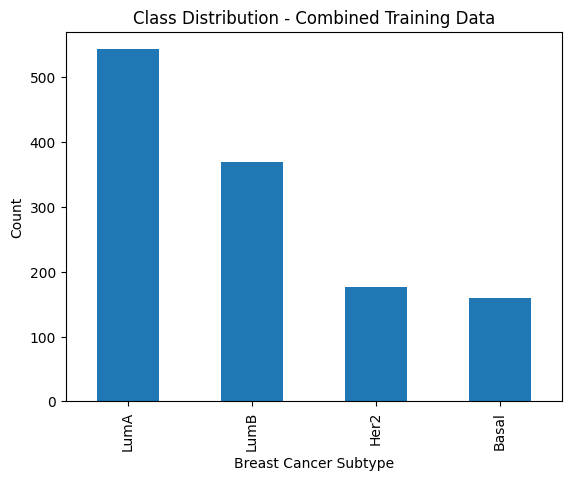

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

y_train_labels = le.inverse_transform(y_train_c)

pd.Series(y_train_labels).value_counts().plot(kind="bar")
plt.title("Class Distribution - Combined Training Data")
plt.xlabel("Breast Cancer Subtype")
plt.ylabel("Count")
plt.show()

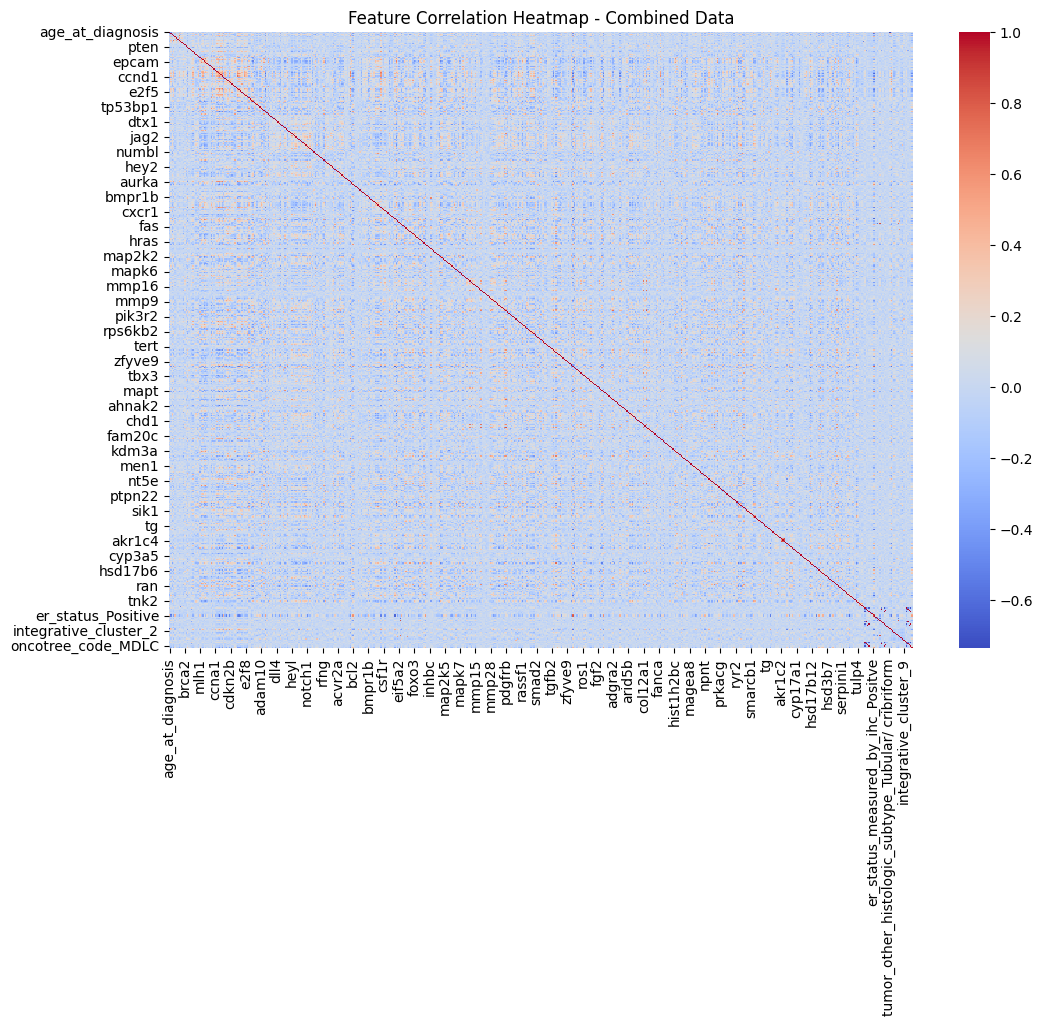

In [31]:
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.heatmap(X_train_c.corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap - Combined Data")
plt.show()

In [22]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

log_combined = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

log_combined.fit(X_train_c, y_train_c)

y_pred_log_c = log_combined.predict(X_test_c)

print("Combined Logistic Accuracy:", accuracy_score(y_test_c, y_pred_log_c))
print(classification_report(y_test_c, y_pred_log_c, target_names=le.classes_))

Combined Logistic Accuracy: 0.7916666666666666
              precision    recall  f1-score   support

       Basal       0.89      0.85      0.87        40
        Her2       0.66      0.80      0.72        44
        LumA       0.85      0.83      0.84       136
        LumB       0.74      0.71      0.72        92

    accuracy                           0.79       312
   macro avg       0.79      0.80      0.79       312
weighted avg       0.80      0.79      0.79       312



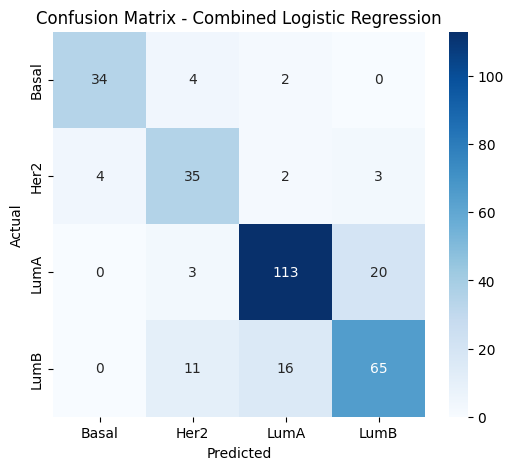

In [25]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_log = confusion_matrix(y_test_c, y_pred_log_c)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_log,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Combined Logistic Regression")
plt.show()

In [26]:
from sklearn.ensemble import RandomForestClassifier

rf_combined = RandomForestClassifier(
    n_estimators=300,
    min_samples_split=10,
    max_depth=None,
    random_state=42,
    class_weight="balanced"
)

rf_combined.fit(X_train_c, y_train_c)

y_pred_rf_c = rf_combined.predict(X_test_c)

print("Combined RF Accuracy:", accuracy_score(y_test_c, y_pred_rf_c))
print(classification_report(y_test_c, y_pred_rf_c, target_names=le.classes_))

Combined RF Accuracy: 0.8685897435897436
              precision    recall  f1-score   support

       Basal       1.00      0.82      0.90        40
        Her2       0.90      0.84      0.87        44
        LumA       0.87      0.90      0.88       136
        LumB       0.81      0.85      0.83        92

    accuracy                           0.87       312
   macro avg       0.90      0.85      0.87       312
weighted avg       0.87      0.87      0.87       312



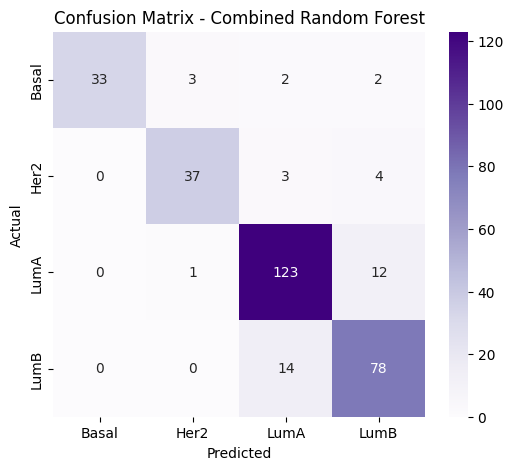

In [27]:
cm_rf = confusion_matrix(y_test_c, y_pred_rf_c)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Combined Random Forest")
plt.show()

In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_c_scaled = scaler.fit_transform(X_train_c)
X_test_c_scaled = scaler.transform(X_test_c)

In [34]:
import torch

X_train_c_tensor = torch.tensor(X_train_c_scaled, dtype=torch.float32)
X_test_c_tensor = torch.tensor(X_test_c_scaled, dtype=torch.float32)

y_train_c_tensor = torch.tensor(y_train_c, dtype=torch.long)
y_test_c_tensor = torch.tensor(y_test_c, dtype=torch.long)

In [35]:
import torch.nn as nn

class MLP(nn.Module):
    def __init__(self, input_size, num_classes):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.model(x)

mlp_combined = MLP(input_size=X_train_c.shape[1], num_classes=4)

In [36]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(mlp_combined.parameters(), lr=0.001)

In [37]:
losses = []
epochs = 20

for epoch in range(epochs):
    mlp_combined.train()

    outputs = mlp_combined(X_train_c_tensor)
    loss = criterion(outputs, y_train_c_tensor)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 5, Loss: 1.0734
Epoch 10, Loss: 0.7205
Epoch 15, Loss: 0.5027
Epoch 20, Loss: 0.3861


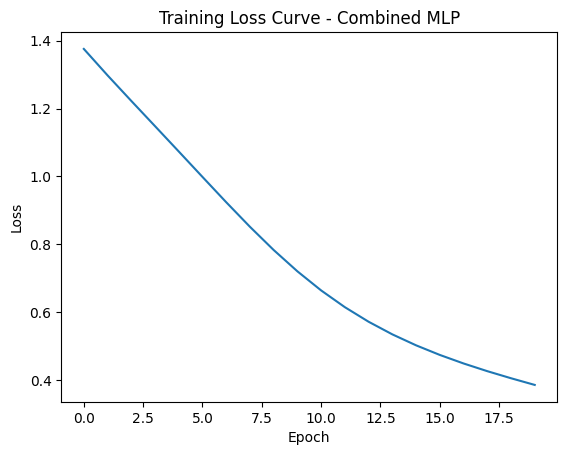

In [38]:
import matplotlib.pyplot as plt

plt.plot(losses)
plt.title("Training Loss Curve - Combined MLP")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [39]:
from sklearn.metrics import accuracy_score, classification_report

mlp_combined.eval()

with torch.no_grad():
    outputs = mlp_combined(X_test_c_tensor)
    _, preds_c = torch.max(outputs, 1)

print("Combined MLP Accuracy:", accuracy_score(y_test_c, preds_c.numpy()))
print(classification_report(y_test_c, preds_c.numpy(), target_names=le.classes_))

Combined MLP Accuracy: 0.8173076923076923
              precision    recall  f1-score   support

       Basal       0.95      0.88      0.91        40
        Her2       0.84      0.82      0.83        44
        LumA       0.83      0.82      0.82       136
        LumB       0.74      0.79      0.77        92

    accuracy                           0.82       312
   macro avg       0.84      0.83      0.83       312
weighted avg       0.82      0.82      0.82       312



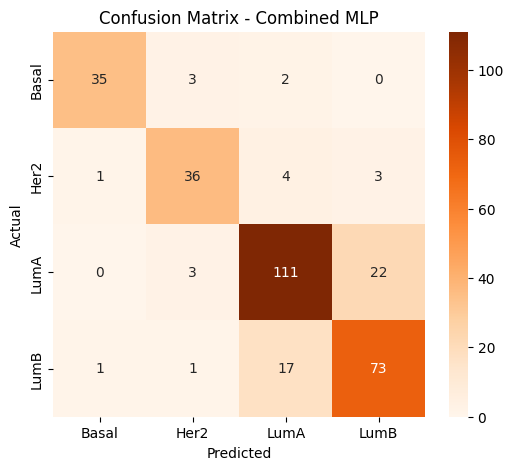

In [40]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm_mlp_c = confusion_matrix(y_test_c, preds_c.numpy())

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_mlp_c,
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Combined MLP")
plt.show()

In [41]:
X_train_ae_tensor = torch.tensor(X_train_c_scaled, dtype=torch.float32)
X_test_ae_tensor = torch.tensor(X_test_c_scaled, dtype=torch.float32)

In [42]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, input_dim)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

ae_model = Autoencoder(input_dim=X_train_c_scaled.shape[1])

In [43]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(ae_model.parameters(), lr=0.001)

In [44]:
ae_losses = []
epochs = 20

for epoch in range(epochs):
    ae_model.train()

    reconstructed = ae_model(X_train_ae_tensor)
    loss = criterion(reconstructed, X_train_ae_tensor)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    ae_losses.append(loss.item())

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 5, Loss: 1.0005
Epoch 10, Loss: 0.9913
Epoch 15, Loss: 0.9628
Epoch 20, Loss: 0.9165


In [45]:
ae_model.eval()

with torch.no_grad():
    reconstructed_test = ae_model(X_test_ae_tensor)
    test_loss = criterion(reconstructed_test, X_test_ae_tensor)

print("Combined Autoencoder Test Reconstruction Loss:", test_loss.item())

Combined Autoencoder Test Reconstruction Loss: 0.9142165780067444


In [47]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

rf_cv = RandomForestClassifier(
    n_estimators=300,
    min_samples_split=10,
    max_depth=None,
    random_state=42,
    class_weight="balanced"
)

cv_scores = cross_val_score(
    rf_cv,
    X_combined_encoded,
    y_combined_encoded,   # ✅ fixed here
    cv=5
)

print("Cross-validation scores:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())

Cross-validation scores: [0.81089744 0.83012821 0.84294872 0.83333333 0.79421222]
Mean CV accuracy: 0.8223039821914421


In [48]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42, class_weight="balanced")

param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5, 10]
}

rf_random_combined = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=5,
    cv=3,
    random_state=42,
    n_jobs=-1
)

rf_random_combined.fit(X_train_c, y_train_c)

print("Best Parameters (Combined):", rf_random_combined.best_params_)

Best Parameters (Combined): {'n_estimators': 300, 'min_samples_split': 10, 'max_depth': None}


In [49]:
best_rf_combined = rf_random_combined.best_estimator_

y_pred_best_c = best_rf_combined.predict(X_test_c)

from sklearn.metrics import accuracy_score, classification_report

print("Tuned Combined RF Accuracy:", accuracy_score(y_test_c, y_pred_best_c))
print(classification_report(y_test_c, y_pred_best_c, target_names=le.classes_))

Tuned Combined RF Accuracy: 0.8685897435897436
              precision    recall  f1-score   support

       Basal       1.00      0.82      0.90        40
        Her2       0.90      0.84      0.87        44
        LumA       0.87      0.90      0.88       136
        LumB       0.81      0.85      0.83        92

    accuracy                           0.87       312
   macro avg       0.90      0.85      0.87       312
weighted avg       0.87      0.87      0.87       312



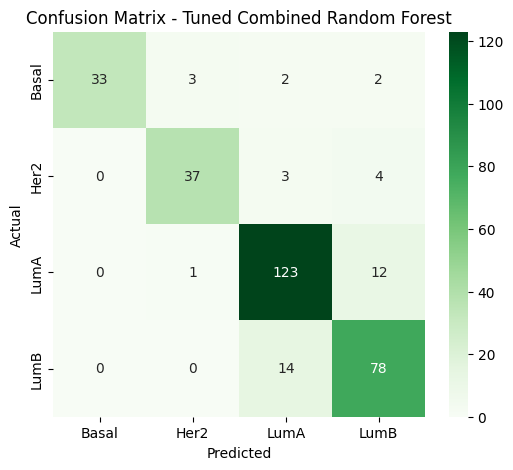

In [50]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_best_c = confusion_matrix(y_test_c, y_pred_best_c)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_best_c,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Tuned Combined Random Forest")
plt.show()